In [ ]:
pip install hub

In [ ]:
import os
print(os.getcwd())

/content


In [ ]:
!git clone https://github.com/Jakobovski/free-spoken-digit-dataset.git

fatal: destination path 'free-spoken-digit-dataset' already exists and is not an empty directory.


#  **Time-Domain Analysis**

This code performs time-domain analysis on the Free-Spoken Digit Dataset (FSDD). It loads each audio file, removes silence, and normalizes the signal. Then it extracts several time-domain features such as zero-crossing rate, RMS energy, signal envelope, and autocorrelation.

These features describe how the signal behaves over time, including its energy, shape, and periodicity. After extracting the features, the code splits the data into training and testing sets, scales the features, and trains a Random Forest classifier to recognize the spoken digits.

Finally, the code evaluates the model accuracy and generates plots such as waveform with envelope, autocorrelation, confusion matrix, and feature comparisons to help understand the results.

In [ ]:
import numpy as np
import librosa
import pandas as pd
from pathlib import Path
from scipy.signal import hilbert
from scipy.stats import skew, kurtosis
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from scipy.signal import hilbert

# ==============================
# DATASET PATH
# ==============================
DATA_DIR = Path("/content/free-spoken-digit-dataset/recordings")
files = sorted(DATA_DIR.glob("*.wav"))

if len(files) == 0:
    raise FileNotFoundError("No .wav files found. Check DATA_DIR.")


# ==============================
# HELPER FUNCTIONS
# ==============================
def parse_filename(file_path):
    parts = file_path.stem.split("_")
    digit = int(parts[0])
    speaker = parts[1]
    index = int(parts[2])
    return digit, speaker, index


def load_audio(file_path):
    y, sr = librosa.load(file_path, sr=None, mono=True)

    # Remove silence
    y, _ = librosa.effects.trim(y, top_db=20)

    # Normalize amplitude
    max_abs = np.max(np.abs(y))
    if max_abs > 0:
        y = y / max_abs

    return y, sr


def safe_stats(x):
    x = np.asarray(x)

    if len(x) == 0:
        return [0, 0, 0, 0, 0, 0]

    std = np.std(x)

    if std == 0:
        return [
            np.min(x),
            np.max(x),
            np.mean(x),
            std,
            0,
            0
        ]

    return [
        np.min(x),
        np.max(x),
        np.mean(x),
        std,
        skew(x),
        kurtosis(x)
    ]


def autocorrelation_features(y, sr):
    y = y - np.mean(y)

    autocorr = np.correlate(y, y, mode="full")
    autocorr = autocorr[len(autocorr)//2:]

    if autocorr[0] != 0:
        autocorr = autocorr / autocorr[0]

    # pitch-related region: 5 ms to 30 ms
    start = int(0.005 * sr)
    end = int(0.030 * sr)

    region = autocorr[start:end]

    if len(region) == 0:
        return [0, 0, 0, 0]

    peak = np.max(region)
    mean = np.mean(region)
    std = np.std(region)
    peak_lag_ms = (np.argmax(region) + start) * 1000 / sr

    return [peak, mean, std, peak_lag_ms]


# ==============================
# FEATURE EXTRACTION
# ==============================
def extract_features(file_path):
    y, sr = load_audio(file_path)

    if len(y) < 10:
        return None

    # Zero-crossing rate
    zcr = librosa.feature.zero_crossing_rate(y=y)[0]
    zcr_features = safe_stats(zcr)

    # RMS energy
    rms = librosa.feature.rms(y=y)[0]
    rms_features = safe_stats(rms)

    # Envelope
    envelope = np.abs(hilbert(y))
    envelope_features = safe_stats(envelope)

    # Global time-domain features
    duration = len(y) / sr
    energy = np.sum(y ** 2)
    abs_mean = np.mean(np.abs(y))
    variance = np.var(y)
    peak = np.max(np.abs(y))

    signal_rms = np.sqrt(np.mean(y ** 2)) + 1e-8
    crest_factor = peak / signal_rms

    # Silence ratio after trimming
    silence_ratio = np.mean(np.abs(y) < 0.02)

    # Autocorrelation features
    ac_features = autocorrelation_features(y, sr)

    features = (
        zcr_features +
        rms_features +
        envelope_features +
        [
            duration,
            energy,
            abs_mean,
            variance,
            peak,
            crest_factor,
            silence_ratio
        ] +
        ac_features
    )

    return np.array(features, dtype=float)


# ==============================
# BUILD DATASET
# ==============================
X = []
y = []
filenames = []

for f in files:
    digit, speaker, index = parse_filename(f)
    features = extract_features(f)

    if features is None:
        continue

    X.append(features)
    y.append(digit)
    filenames.append(f.name)

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)


# ==============================
# TRAIN / TEST SPLIT
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.1,
    stratify=y,
    random_state=42
)


# ==============================
# SCALE FEATURES
# ==============================
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# ==============================
# RANDOM FOREST MODEL
# ==============================
model = RandomForestClassifier(
    n_estimators=600,
    max_depth=25,
    min_samples_split=3,
    min_samples_leaf=1,
    max_features="sqrt",
    random_state=42
)

model.fit(X_train, y_train)


# ==============================
# EVALUATION
# ==============================
y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)

print("\n==============================")
print("IMPROVED TIME-DOMAIN RESULTS")
print("==============================")
print(f"Accuracy: {acc * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

X shape: (3000, 29)
y shape: (3000,)

IMPROVED TIME-DOMAIN RESULTS
Accuracy: 74.00%

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.83      0.81        30
           1       0.77      0.67      0.71        30
           2       0.65      0.73      0.69        30
           3       0.48      0.53      0.51        30
           4       0.68      0.77      0.72        30
           5       0.78      0.60      0.68        30
           6       0.87      0.90      0.89        30
           7       0.81      0.83      0.82        30
           8       0.85      0.77      0.81        30
           9       0.79      0.77      0.78        30

    accuracy                           0.74       300
   macro avg       0.75      0.74      0.74       300
weighted avg       0.75      0.74      0.74       300


Confusion Matrix:
[[25  0  1  2  1  0  0  0  0  1]
 [ 2 20  0  2  1  0  0  2  1  2]
 [ 1  0 22  6  1  0  0  0  0  0]
 [ 1  0  7 16  

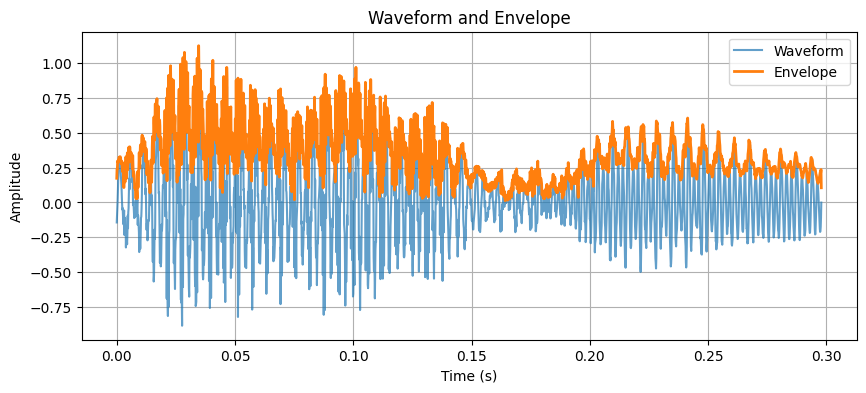

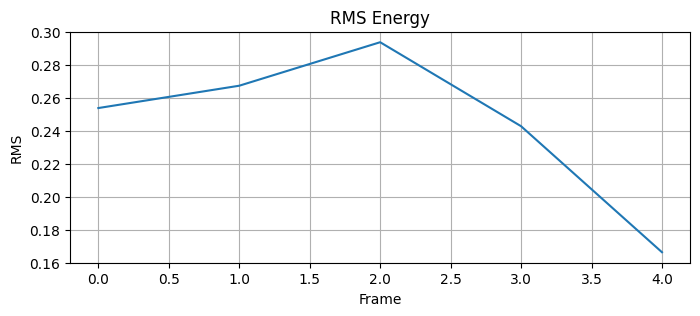

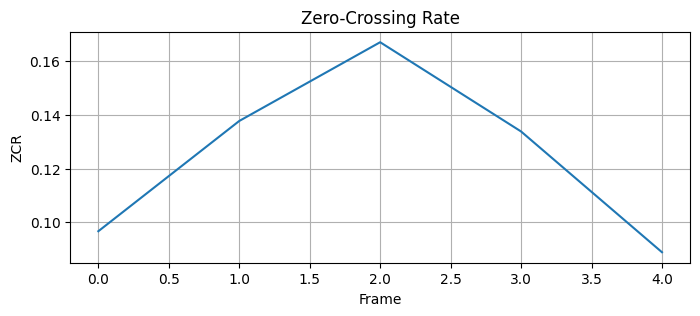

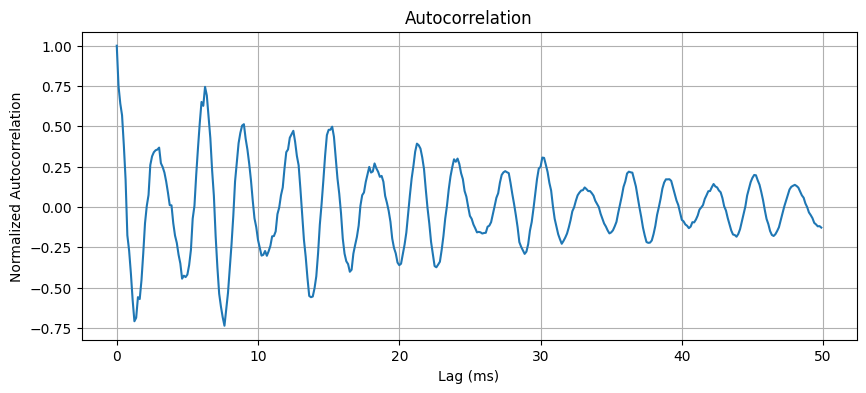

In [ ]:
example_file = files[0]
y_ex, sr_ex = load_audio(example_file)

time = np.arange(len(y_ex)) / sr_ex

# Compute features for plotting
zcr_ex = librosa.feature.zero_crossing_rate(y=y_ex)[0]
rms_ex = librosa.feature.rms(y=y_ex)[0]
envelope_ex = np.abs(hilbert(y_ex))
autocorr_ex = autocorrelation_full(y_ex)


# 1. Waveform + Envelope
plt.figure(figsize=(10, 4))
plt.plot(time, y_ex, label="Waveform", alpha=0.7)
plt.plot(time, envelope_ex, label="Envelope", linewidth=2)
plt.title("Waveform and Envelope")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.show()


# 2. RMS Energy
plt.figure(figsize=(8, 3))
plt.plot(rms_ex)
plt.title("RMS Energy")
plt.xlabel("Frame")
plt.ylabel("RMS")
plt.grid(True)
plt.show()


# 3. Zero-Crossing Rate
plt.figure(figsize=(8, 3))
plt.plot(zcr_ex)
plt.title("Zero-Crossing Rate")
plt.xlabel("Frame")
plt.ylabel("ZCR")
plt.grid(True)
plt.show()


# 4. Autocorrelation
max_lag_ms = 50
max_lag_samples = int((max_lag_ms / 1000) * sr_ex)
lags_ms = np.arange(max_lag_samples) * 1000 / sr_ex

plt.figure(figsize=(10, 4))
plt.plot(lags_ms, autocorr_ex[:max_lag_samples])
plt.title("Autocorrelation")
plt.xlabel("Lag (ms)")
plt.ylabel("Normalized Autocorrelation")
plt.grid(True)
plt.show()

# Discrete Fourier Transform (DFT) Analysis

The Discrete Fourier Transform (DFT) provides a frequency-domain representation of a signal by analyzing it as a whole and decomposing it into its frequency components. In this work, the DFT was implemented using the Fast Fourier Transform (FFT) for efficient computation.

Unlike the Short-Time Fourier Transform (STFT), which analyzes signals over short segments, the DFT processes the entire signal at once and therefore does not capture time variations in frequency content. This makes it less suitable for non-stationary signals such as speech.
### Mathematical Definition

The DFT of a discrete-time signal x[n] is defined as:
$$
X[k] = \sum_{n=0}^{N-1} x[n] \, e^{-j \frac{2\pi}{N} k n}
$$

### Implementation in This Work

In this work, each audio signal was preprocessed by removing silence and normalizing the amplitude. A Hanning window was applied before computing the FFT to reduce spectral leakage.

The FFT was then computed on the entire signal to obtain the frequency-domain representation. From this representation, several spectral features were extracted.


### Extracted Features
The following features were extracted from the DFT spectrum:

- spectral centroid  
- spectral bandwidth  
- spectral rolloff (85%)  
- dominant frequency  
- spectral entropy  
- spectral flatness  
- band energy ratios (0–500 Hz, 500–1000 Hz, 1000–2000 Hz, 2000–4000 Hz)  
- skewness  
- kurtosis  
- ZCR

These features summarize the frequency characteristics of the signal and are used as input to the classification model.



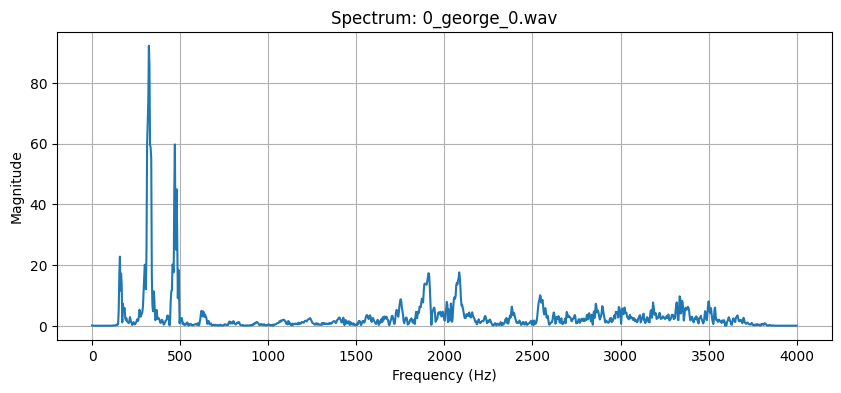

In [ ]:
import librosa
import numpy as np
import matplotlib.pyplot as plt

# Choose one audio file
file_path = DATA_DIR / "0_george_0.wav"
# Load audio
y, sr = librosa.load(file_path, sr=None, mono=True)
# Remove silence
y, _ = librosa.effects.trim(y, top_db=20)
# Normalize
y = y / np.max(np.abs(y))
# Apply Hanning window
N = len(y)
x = y * np.hanning(N)
# Compute FFT
X = np.fft.rfft(x)
# Magnitude spectrum
mag = np.abs(X)
# Frequency axis
freqs = np.fft.rfftfreq(N, d=1/sr)
# Plot spectrum
plt.figure(figsize=(10, 4))
plt.plot(freqs, mag)
plt.title("Spectrum: 0_george_0.wav")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.grid(True)
plt.show()

def extract_dft_features(file_path):
    y, sr = librosa.load(file_path, sr=None, mono=True)
    y, _ = librosa.effects.trim(y, top_db=20)
     # Remove silence from beginning and end
    y = y / np.max(np.abs(y))
    # Normalize signal amplitude to range [-1, 1]


    N = len(y)
    x = y * np.hanning(N) # Apply Hanning window to reduce spectral leakage


    X = np.fft.rfft(x)
    mag = np.abs(X) # Compute magnitude spectrum (strength of each frequency)
    freqs = np.fft.rfftfreq(N, d=1/sr)  # Get frequency values corresponding to FFT bins

    power = mag ** 2
    power_sum = np.sum(power) + 1e-12

    # Feature 1
    centroid = np.sum(freqs * power) / power_sum # Spectral centroid: weighted average of frequencies (center of energy)
    # Feature 2
    bandwidth = np.sqrt(
        np.sum(((freqs - centroid) ** 2) * power) / power_sum
    ) # Spectral bandwidth: spread of frequencies around the centroid

    cumulative_energy = np.cumsum(power)
    rolloff_threshold = 0.85 * cumulative_energy[-1]
    rolloff_idx = np.searchsorted(cumulative_energy, rolloff_threshold)
    rolloff = freqs[min(rolloff_idx, len(freqs) - 1)] # Frequency where 85% of energy is contained #Feature 3

    mag_no_dc = mag.copy() # Copy magnitude spectrum to avoid modifying original
    mag_no_dc[0] = 0 # Remove the DC component
    dominant_idx = np.argmax(mag_no_dc) # Find index of the strongest frequency (highest magnitude)
    dominant_freq = freqs[dominant_idx] #Feature 4

    p = power / power_sum
    #Feature 5
    entropy = -np.sum(p * np.log2(p + 1e-12)) # Compute spectral entropy (measure of randomness in frequency distribution)

    #Feature 6
    def band_energy_ratio(f_low, f_high):
        idx = np.where((freqs >= f_low) & (freqs < f_high))[0]
        if len(idx) == 0:
            return 0.0
        return np.sum(power[idx]) / power_sum # Measure energy distribution across frequency bands

    band_0_500 = band_energy_ratio(0, 500)
    band_500_1000 = band_energy_ratio(500, 1000)
    band_1000_2000 = band_energy_ratio(1000, 2000)
    band_2000_4000 = band_energy_ratio(2000, 4000)

    #Feature 6
    flatness = np.exp(np.mean(np.log(mag + 1e-12))) / (np.mean(mag) + 1e-12) # Spectral flatness: indicates whether the signal is noise-like or tone-like

    mean_freq = centroid
    #Feature 7
    skewness = np.sum(((freqs - mean_freq)**3) * power) / (power_sum * (bandwidth**3 + 1e-12)) # Skewness: asymmetry of frequency distribution
    #Feature 8
    kurtosis = np.sum(((freqs - mean_freq)**4) * power) / (power_sum * (bandwidth**4 + 1e-12)) # Kurtosis: sharpness of spectral peak
    #Feature 9
    zcr = np.mean(librosa.feature.zero_crossing_rate(y))




    return [
        centroid,
        bandwidth,
        rolloff,
        dominant_freq,
        entropy,
        band_0_500,
        band_500_1000,
        band_1000_2000,
        band_2000_4000,
        flatness,
        skewness,
        kurtosis,
        zcr
    ]

# Build dataset: extract features and labels from all audio files
X = []
y = []

import os

for file_name in os.listdir(DATA_DIR):
    if file_name.endswith(".wav"):
        file_path = DATA_DIR / file_name
        digit = int(file_name.split("_")[0])
        features = extract_dft_features(file_path)

        X.append(features)
        y.append(digit)


In [ ]:
# Build dataset: extract features and labels from all audio files
X = []
y = []

import os

for file_name in os.listdir(DATA_DIR):
    if file_name.endswith(".wav"):
        file_path = DATA_DIR / file_name
        digit = int(file_name.split("_")[0])
        features = extract_dft_features(file_path)

        X.append(features)
        y.append(digit)

X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)


# Split dataset into training and testing sets (90% train, 10% test)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.1,
    random_state=42,
    stratify=y
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))

# Scale features to reduce effect of outliers
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
print(X_train.shape)
print(X_test.shape)


# Train Random Forest model and evaluate accuracy
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

model = RandomForestClassifier(
    n_estimators=400,
    max_depth=20,
    min_samples_leaf=1,
    random_state=42
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

(3000, 13)
(3000,)
Train size: 2700
Test size: 300
(2700, 13)
(300, 13)
Accuracy: 0.8566666666666667



Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.87      0.91        30
           1       0.79      0.87      0.83        30
           2       0.83      0.80      0.81        30
           3       0.77      0.77      0.77        30
           4       0.88      0.97      0.92        30
           5       0.85      0.97      0.91        30
           6       0.96      0.90      0.93        30
           7       0.82      0.77      0.79        30
           8       0.85      0.93      0.89        30
           9       0.88      0.73      0.80        30

    accuracy                           0.86       300
   macro avg       0.86      0.86      0.86       300
weighted avg       0.86      0.86      0.86       300


Feature Importance:

                feature  importance
12                  zcr    0.123760
6            band_0_500    0.101384
7         band_500_1000    0.093213
2   spectral_rolloff_85    0.092587
8        band_

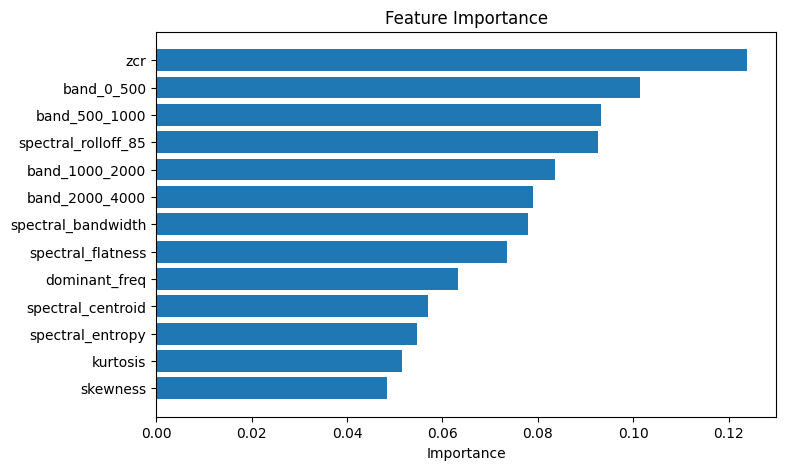

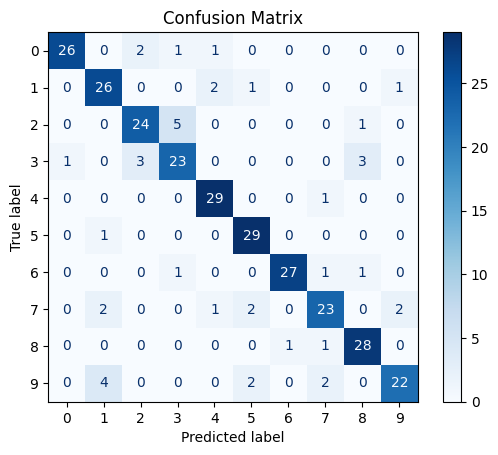

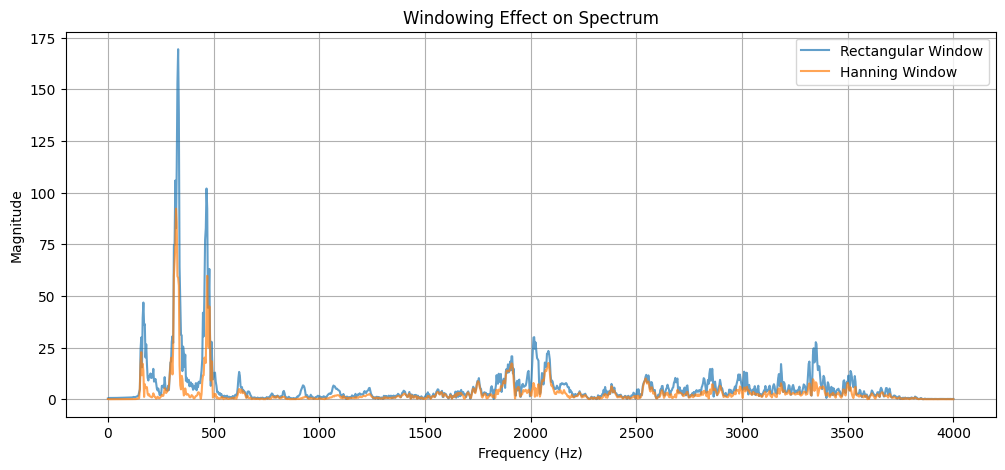

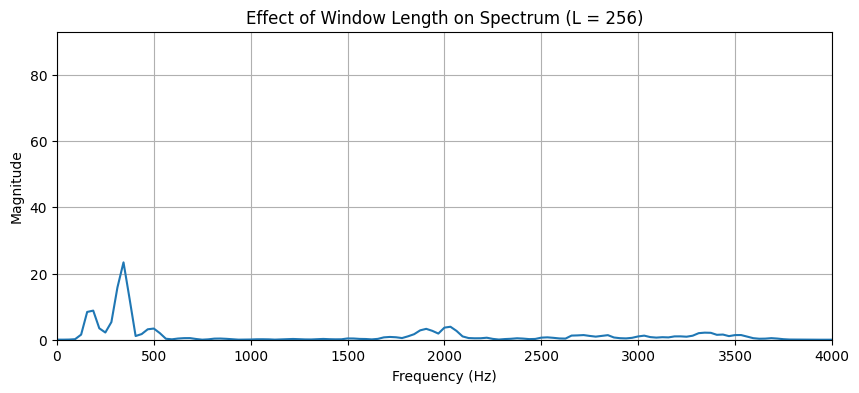

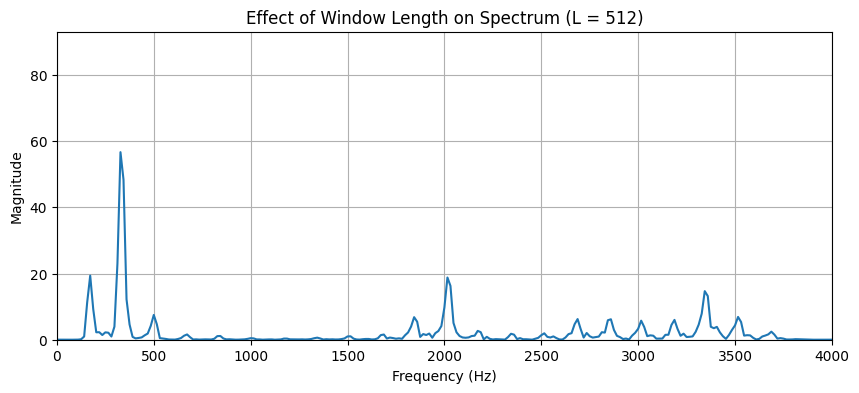

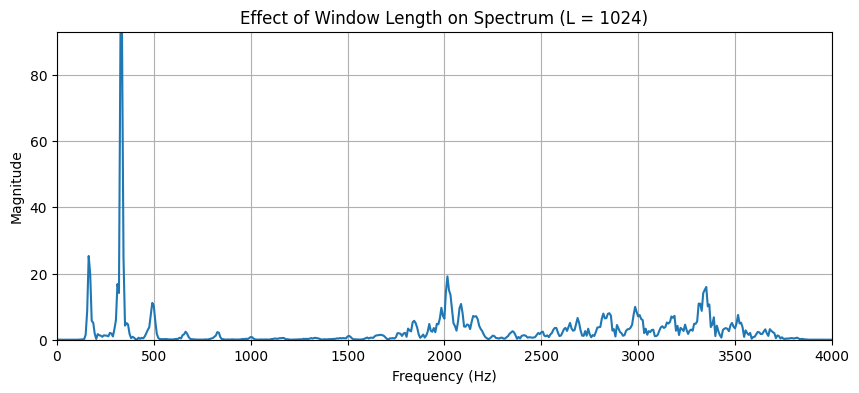

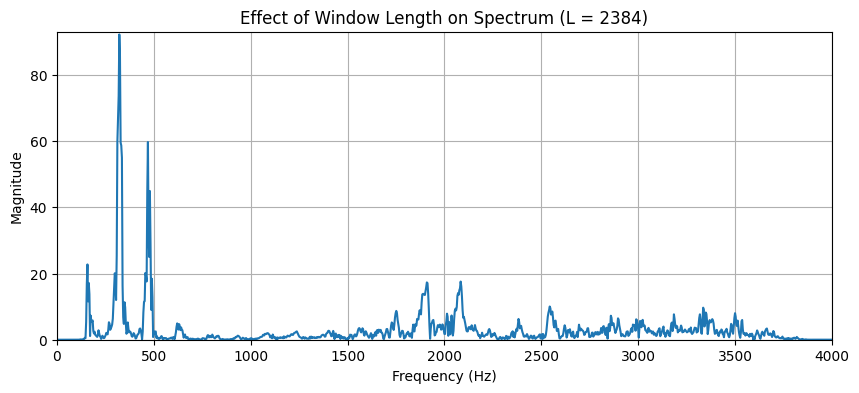

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import librosa


# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))



# Feature Importance
feature_names = [
    "spectral_centroid",
    "spectral_bandwidth",
    "spectral_rolloff_85",
    "dominant_freq",
    "spectral_entropy",
    "spectral_flatness",
    "band_0_500",
    "band_500_1000",
    "band_1000_2000",
    "band_2000_4000",
    "skewness",
    "kurtosis",
    "zcr"
]

importances = model.feature_importances_

df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
})

df = df.sort_values(by="importance", ascending=False)

print("\nFeature Importance:\n")
print(df)


# Plot Feature Importance
plt.figure(figsize=(8, 5))
plt.barh(df["feature"], df["importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.show()


# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()


# Windowing Effect: Rectangular vs Hanning
file_path = DATA_DIR / "0_george_0.wav"

y, sr = librosa.load(file_path, sr=None, mono=True)
y, _ = librosa.effects.trim(y, top_db=20)

max_abs = np.max(np.abs(y))
if max_abs > 0:
    y = y / max_abs

# Rectangular window = no window applied
X_rect = np.fft.rfft(y)
mag_rect = np.abs(X_rect)
freqs = np.fft.rfftfreq(len(y), d=1/sr)

# Hanning window
hanning_window = np.hanning(len(y))
y_hanning = y * hanning_window

X_hanning = np.fft.rfft(y_hanning)
mag_hanning = np.abs(X_hanning)

plt.figure(figsize=(12, 5))
plt.plot(freqs, mag_rect, label="Rectangular Window", alpha=0.7)
plt.plot(freqs, mag_hanning, label="Hanning Window", alpha=0.7)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.title("Windowing Effect on Spectrum")
plt.legend()
plt.grid(True)
plt.show()


# Window Length Effect - Separate Plots
window_lengths = [256, 512, 1024, len(y)]


max_mag = 0
results = []

for L in window_lengths:
    if L > len(y):
        L = len(y)

    x = y[:L]

    window = np.hanning(len(x))
    x_windowed = x * window

    X_fft = np.fft.rfft(x_windowed)
    mag = np.abs(X_fft)
    freqs = np.fft.rfftfreq(len(x), d=1/sr)

    results.append((L, freqs, mag))
    max_mag = max(max_mag, np.max(mag))
# The following visualization code was created with assistance from ChatGPT
for L, freqs, mag in results:
    plt.figure(figsize=(10, 4))
    plt.plot(freqs, mag)

    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude")
    plt.title(f"Effect of Window Length on Spectrum (L = {L})")

    plt.xlim(0, 4000)
    plt.ylim(0, max_mag)

    plt.grid(True)
    plt.show()

### Frequency Resolution

The frequency resolution depends on the FFT size
$$
\Delta f = \frac{f_s}{N}
$$
Different values of N were tested to analyze the effect of frequency resolution on classification performance.


N_FFT = 256  Accuracy = 0.850000
N_FFT = 512  Accuracy = 0.850000
N_FFT = 1024  Accuracy = 0.850000
N_FFT = 2048  Accuracy = 0.843333
N_FFT = 4096  Accuracy = 0.876667
N = 256  →  Δf = 31.2500 Hz
N = 512  →  Δf = 15.6250 Hz
N = 1024  →  Δf = 7.8125 Hz
N = 2048  →  Δf = 3.9062 Hz
N = 4096  →  Δf = 1.9531 Hz


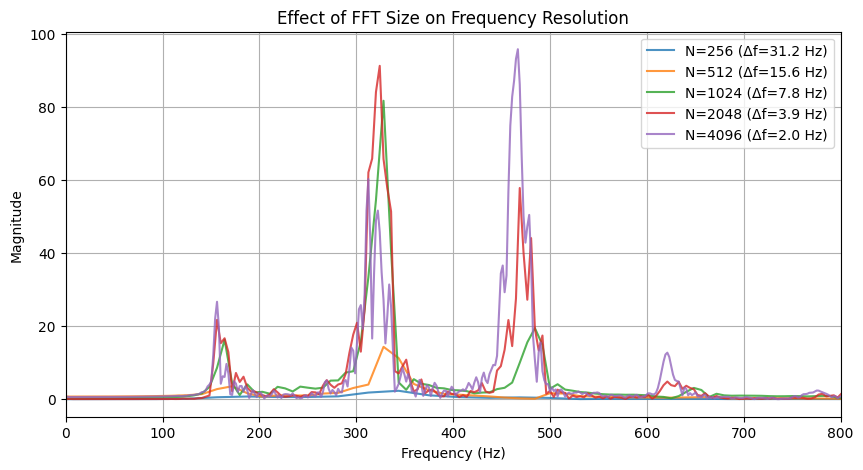

In [ ]:
import os
import numpy as np
import librosa
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Function: Extract DFT features using specific FFT size
def extract_dft_features_N(file_path, N_FFT):
    y, sr = librosa.load(file_path, sr=None, mono=True)

    y, _ = librosa.effects.trim(y, top_db=20)

    max_abs = np.max(np.abs(y))
    if max_abs > 0:
        y = y / max_abs

    x = y.copy()

    # Zero-padding only if N_FFT is larger than signal length
    if N_FFT > len(x):
        x = np.pad(x, (0, N_FFT - len(x)))

    # Apply Hanning window
    x = x * np.hanning(len(x))

    # Compute FFT using N_FFT if padded, otherwise full signal length
    fft_len = len(x)

    X = np.fft.rfft(x, n=fft_len)
    mag = np.abs(X)
    freqs = np.fft.rfftfreq(fft_len, d=1/sr)

    power = mag ** 2
    power_sum = np.sum(power) + 1e-12

    centroid = np.sum(freqs * power) / power_sum

    bandwidth = np.sqrt(
        np.sum(((freqs - centroid) ** 2) * power) / power_sum
    )

    cumulative_energy = np.cumsum(power)
    rolloff_threshold = 0.85 * cumulative_energy[-1]
    rolloff_idx = np.searchsorted(cumulative_energy, rolloff_threshold)
    rolloff = freqs[min(rolloff_idx, len(freqs) - 1)]

    mag_no_dc = mag.copy()
    mag_no_dc[0] = 0
    dominant_idx = np.argmax(mag_no_dc)
    dominant_freq = freqs[dominant_idx]

    p = power / power_sum
    entropy = -np.sum(p * np.log2(p + 1e-12))

    flatness = np.exp(np.mean(np.log(mag + 1e-12))) / (np.mean(mag) + 1e-12)

    def band_energy_ratio(f_low, f_high):
        idx = np.where((freqs >= f_low) & (freqs < f_high))[0]
        if len(idx) == 0:
            return 0.0
        return np.sum(power[idx]) / power_sum

    band_0_500 = band_energy_ratio(0, 500)
    band_500_1000 = band_energy_ratio(500, 1000)
    band_1000_2000 = band_energy_ratio(1000, 2000)
    band_2000_4000 = band_energy_ratio(2000, 4000)

    mean_freq = centroid

    skewness = np.sum(((freqs - mean_freq) ** 3) * power) / (
        power_sum * (bandwidth ** 3 + 1e-12)
    )

    kurtosis = np.sum(((freqs - mean_freq) ** 4) * power) / (
        power_sum * (bandwidth ** 4 + 1e-12)
    )
    zcr = np.mean(librosa.feature.zero_crossing_rate(y))

    return [
        centroid,
        bandwidth,
        rolloff,
        dominant_freq,
        entropy,
        flatness,
        band_0_500,
        band_500_1000,
        band_1000_2000,
        band_2000_4000,
        skewness,
        kurtosis,
        zcr
    ]


# Experiment: Test different FFT sizes
for N in [256, 512, 1024, 2048, 4096]:

    X_exp = []
    y_exp = []

    for file_name in os.listdir(DATA_DIR):
        if file_name.endswith(".wav"):
            file_path = DATA_DIR / file_name
            digit = int(file_name.split("_")[0])

            features = extract_dft_features_N(file_path, N)

            X_exp.append(features)
            y_exp.append(digit)

    X_exp = np.array(X_exp)
    y_exp = np.array(y_exp)

    X_train_exp, X_test_exp, y_train_exp, y_test_exp = train_test_split(
        X_exp,
        y_exp,
        test_size=0.1,
        random_state=42,
        stratify=y_exp
    )

    model = RandomForestClassifier(
        n_estimators=400,
        max_depth=20,
        min_samples_leaf=1,
        random_state=42
    )

    model.fit(X_train_exp, y_train_exp)

    y_pred_exp = model.predict(X_test_exp)
    acc = accuracy_score(y_test_exp, y_pred_exp)

    print(f"N_FFT = {N}  Accuracy = {acc:.6f}")

# The following visualization code was created with assistance from ChatGPT
# Frequency resolution
file_path = DATA_DIR / "0_george_0.wav"

y, sr = librosa.load(file_path, sr=None, mono=True)
y, _ = librosa.effects.trim(y, top_db=20)

max_abs = np.max(np.abs(y))
if max_abs > 0:
    y = y / max_abs

plt.figure(figsize=(10, 5))

for N in [256, 512, 1024, 2048, 4096]:

    x = y.copy()

    # If N is larger than signal length, apply zero-padding
    if N > len(x):
        x = np.pad(x, (0, N - len(x)))

    # Apply Hanning window
    x = x * np.hanning(len(x))

    # Compute FFT using current N
    X_fft = np.fft.rfft(x, n=N)
    mag = np.abs(X_fft)
    freqs = np.fft.rfftfreq(N, d=1/sr)

    # Frequency resolution
    delta_f = sr / N
    print(f"N = {N}  →  Δf = {delta_f:.4f} Hz")

    plt.plot(freqs, mag, label=f"N={N} (Δf={delta_f:.1f} Hz)", alpha=0.8)

plt.xlim(0, 800)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.title("Effect of FFT Size on Frequency Resolution")
plt.legend()
plt.grid(True)
plt.show()

### Zero-Padding
Zero-padding was applied when the signal length was shorter than the FFT size. This improves the smoothness of the spectrum but does not add new information.

Original signal length: 2384


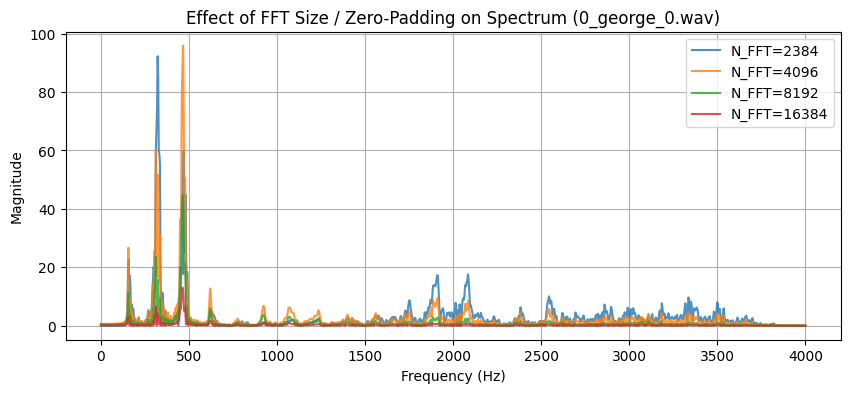

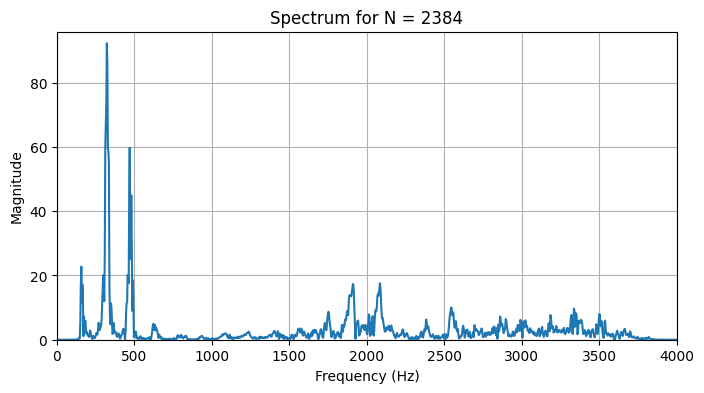

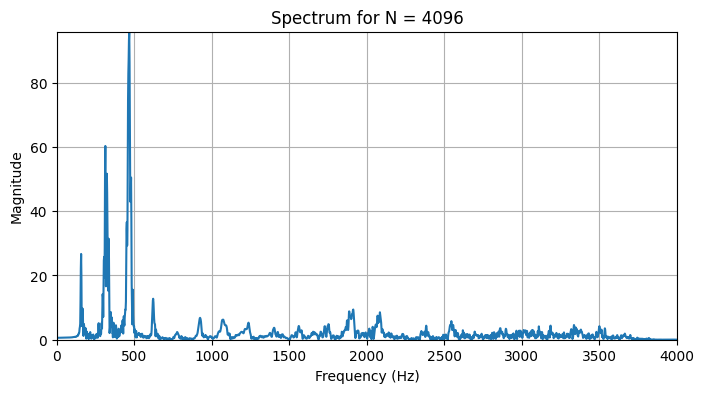

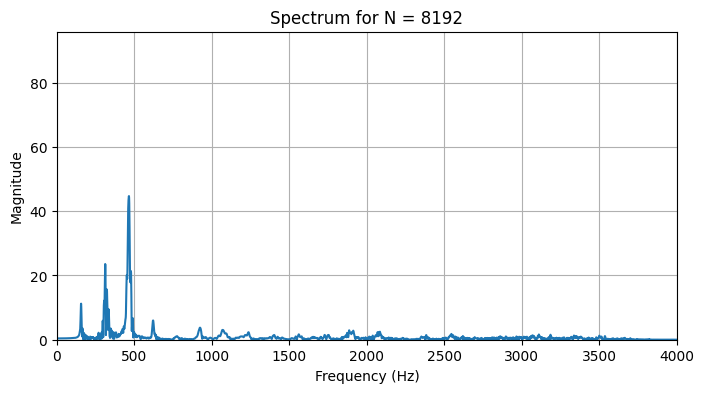

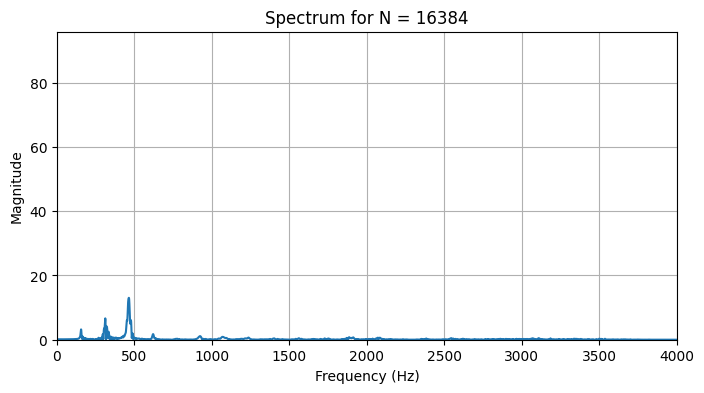

In [ ]:
# Plot: Effect of FFT size / zero-padding on spectrum
file_path = DATA_DIR / "0_george_0.wav"

y, sr = librosa.load(file_path, sr=None, mono=True)
y, _ = librosa.effects.trim(y, top_db=20)

max_abs = np.max(np.abs(y))
if max_abs > 0:
    y = y / max_abs

print("Original signal length:", len(y))

plt.figure(figsize=(10, 4))

# Use values larger than signal length to clearly show zero-padding effect
# The following visualization code was created with assistance from ChatGPT
for N in [len(y), 4096, 8192, 16384]:

    x = y.copy()

    if N > len(x):
        x = np.pad(x, (0, N - len(x)))

    x = x * np.hanning(len(x))

    X_fft = np.fft.rfft(x, n=N)
    mag = np.abs(X_fft)
    freqs = np.fft.rfftfreq(N, d=1/sr)

    plt.plot(freqs, mag, label=f"N_FFT={N}", alpha=0.8)

plt.legend()
plt.title("Effect of FFT Size / Zero-Padding on Spectrum (0_george_0.wav)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.grid(True)
plt.show()

max_mag = 0

results = []

for N in [len(y), 4096, 8192, 16384]:

    x = y.copy()

    if N > len(x):
        x = np.pad(x, (0, N - len(x)))

    x = x * np.hanning(len(x))

    X_fft = np.fft.rfft(x, n=N)
    mag = np.abs(X_fft)
    freqs = np.fft.rfftfreq(N, d=1/sr)

    results.append((freqs, mag, N))

    max_mag = max(max_mag, np.max(mag))

for freqs, mag, N in results:

    plt.figure(figsize=(8,4))
    plt.plot(freqs, mag)

    plt.title(f"Spectrum for N = {N}")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude")

    plt.xlim(0, 4000)
    plt.ylim(0, max_mag)

    plt.grid(True)
    plt.show()

# Short-Time Fourier Transform (STFT) Analysis

The Short-Time Fourier Transform (STFT) provides a time-frequency representation of a signal by dividing it into short segments and applying the Fourier transform to each segment. Unlike the conventional Fourier transform, which analyzes the entire signal at once and therefore loses time localization, the STFT makes it possible to observe how the frequency content changes with time. This is especially useful for speech signals, since they are non-stationary and their spectral content varies during pronunciation.

## Mathematical Definition

The STFT of a discrete-time signal $x[n]$ is defined as:

$$
X[m,k] = \sum_{n=-\infty}^{\infty} x[n] \, w[n-mH] \, e^{-j \frac{2\pi}{N}kn}
$$

where:

- $w[n]$ is the analysis window of length $L$
- $m$ is the window position index
- $H$ is the hop size between successive windows
- $k$ is the frequency-bin index
- $N$ is the FFT size used to compute the spectrum of each segment

The main idea is that each short segment is assumed to be approximately stationary, so its local spectrum can be meaningfully computed. By repeating this process across time, the STFT produces a spectrogram that shows the evolution of spectral energy over both time and frequency.

## Time-Frequency Resolution

A key limitation of the STFT is that it uses a fixed window for the entire signal, which means the time and frequency resolutions are also fixed. A narrow window gives better time resolution but poorer frequency resolution, while a wide window gives better frequency resolution but poorer time resolution. Therefore, selecting the window length is an important design choice in STFT-based analysis.

## Implementation in This Work

In this work, the STFT was implemented using a Hann window with:

- window length $L = 512$ samples
- FFT size $N = 512$
- hop length $H = 64$ samples

Two STFT-based feature extraction approaches were investigated.

### Approach 1: Statistical Summary of Frame-Wise Spectral Features

In the first approach, the magnitude spectrogram was computed for each recording and several short-time spectral descriptors were extracted frame by frame. The extracted features were:

- spectral centroid
- spectral bandwidth
- spectral rolloff
- spectral flatness
- RMS energy
- dominant frequency per frame
- band-energy ratios over the ranges 0--500 Hz, 500--1000 Hz, 1000--2000 Hz, and 2000--4000 Hz

Since each recording contains a different number of frames, every frame-wise feature sequence was converted into a fixed-length representation by computing six statistical measures:

- minimum
- maximum
- mean
- standard deviation
- skewness
- kurtosis

These statistical summaries were concatenated to form the final STFT feature vector for each spoken-digit recording.

### Approach 2: Spectrogram Block-Based Features

In the second approach, the normalized magnitude spectrogram was divided into fixed time-frequency blocks. Instead of summarizing only a few frame-wise spectral descriptors, this method preserved more of the actual spectrogram structure. For each block, two statistical measures were computed:

- block mean
- block standard deviation

These block statistics were concatenated to form the final feature vector. This approach was expected to better capture the distribution of energy across both time and frequency, and therefore preserve more discriminative information for spoken-digit classification.

## Classification Stage

For both approaches, the extracted STFT feature vectors were used as inputs to a Random Forest classifier for spoken-digit recognition. The results of the two approaches were then compared in terms of classification performance and feature representation capability.

In [ ]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from scipy.stats import skew, kurtosis
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import ipywidgets as widgets
from IPython.display import display, clear_output

In [ ]:
# 1) DATASET PATH
DATA_DIR = Path("/content/free-spoken-digit-dataset/recordings")
files = sorted(DATA_DIR.glob("*.wav"))
if len(files) == 0:
    raise FileNotFoundError(f"No .wav files found in: {DATA_DIR}")

In [ ]:
def find_filename(file_path):
    """
    Example:
    7_george_13.wav

    Returns:
    digit   -> 7
    speaker -> george
    index   -> 13
    """
    parts = file_path.stem.split("_")
    digit = int(parts[0])
    speaker = parts[1]
    index = int(parts[2])
    return digit, speaker, index


def build_file_catalog(files):
    """
    Build a list of dictionaries containing file metadata.
    """
    catalog = []
    for f in files:
        digit, speaker, index = find_filename(f)
        catalog.append({
            "path": f,
            "digit": digit,
            "speaker": speaker,
            "index": index
        })
    return catalog


def get_speakers(catalog):
    return sorted({item["speaker"] for item in catalog})


def get_digits_for_speaker(catalog, speaker):
    return sorted({item["digit"] for item in catalog if item["speaker"] == speaker})


def get_indices_for_speaker_digit(catalog, speaker, digit):
    return sorted({
        item["index"]
        for item in catalog
        if item["speaker"] == speaker and item["digit"] == digit
    })


def get_file_by_selection(catalog, speaker, digit, index):
    """
    Return the selected file path based on speaker, digit, and index.
    """
    matches = [
        item["path"]
        for item in catalog
        if item["speaker"] == speaker
        and item["digit"] == digit
        and item["index"] == index
    ]

    if len(matches) == 0:
        return None

    return matches[0]


def load_audio(file_path):
    """
    Load one audio file.
    """
    y, sr = librosa.load(file_path, sr=None, mono=True)
    return y, sr


def plot_spectrum_and_spectrogram(
    file_path,
    n_fft=512,
    win_length=512,
    hop_length=64,
    window="hann"
):
    """
    Plot:
    1) Full-signal FFT spectrum
    2) Linear STFT spectrogram
    """
    if file_path is None:
        print("No matching file found.")
        return

    if win_length > n_fft:
        print("Error: WIN_LENGTH must be less than or equal to N_FFT.")
        return

    if hop_length <= 0:
        print("Error: HOP_LENGTH must be positive.")
        return

    try:
        y, sr = load_audio(file_path)
        # Full-signal FFT spectrum
        Y = np.fft.rfft(y)
        magnitude = np.abs(Y)
        freqs = np.fft.rfftfreq(len(y), d=1/sr)

        # Linear STFT spectrogram
        S = librosa.stft(
            y,
            n_fft=n_fft,
            win_length=win_length,
            hop_length=hop_length,
            window=window
        )
        S_mag = np.abs(S)

        # Plot
        fig, axes = plt.subplots(2, 1, figsize=(12, 10))

        # Top: FFT spectrum
        axes[0].plot(freqs, magnitude)
        axes[0].set_title(f"FFT Spectrum - {file_path.name}")
        axes[0].set_xlabel("Frequency (Hz)")
        axes[0].set_ylabel("Magnitude")
        axes[0].set_xlim(0, sr / 2)
        axes[0].grid(True)

        # Bottom: Linear spectrogram
        img = librosa.display.specshow(
            S_mag,
            sr=sr,
            hop_length=hop_length,
            x_axis="time",
            y_axis="hz",
            ax=axes[1]
        )
        axes[1].set_title(
            f"Linear Spectrogram - {file_path.name}\n"
            f"window={window}, n_fft={n_fft}, win_length={win_length}, hop_length={hop_length}"
        )
        fig.colorbar(img, ax=axes[1], label="Magnitude")

        plt.tight_layout()
        plt.show()

        # Extra info
        duration = len(y) / sr
        print(f"Selected file : {file_path.name}")
        print(f"Duration      : {duration:.4f} s")
        print(f"Sampling rate : {sr} Hz")
        print(f"N_FFT         : {n_fft}")
        print(f"WIN_LENGTH    : {win_length}")
        print(f"HOP_LENGTH    : {hop_length}")
        print(f"WINDOW        : {window}")
        print("Note: the window selection affects the STFT spectrogram.")
        print("The FFT spectrum here is the whole-signal FFT, same as your original code.")

    except Exception as e:
        print(f"Error while plotting: {e}")



# 3) BUILD CATALOG
catalog = build_file_catalog(files)


# 4) CREATE WIDGETS
speaker_dropdown = widgets.Dropdown(
    options=get_speakers(catalog),
    description="Speaker:",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="250px")
)

digit_dropdown = widgets.Dropdown(
    options=[],
    description="Digit:",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="250px")
)

index_dropdown = widgets.Dropdown(
    options=[],
    description="Index:",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="250px")
)

window_dropdown = widgets.Dropdown(
    options=["boxcar", "hann", "hamming"],
    value="hann",
    description="Window:",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="250px")
)

nfft_dropdown = widgets.Dropdown(
    options=[128, 256, 512, 1024],
    value=512,
    description="N_FFT:",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="250px")
)

winlen_dropdown = widgets.Dropdown(
    options=[128, 256, 512, 1024],
    value=512,
    description="WIN_LENGTH:",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="250px")
)

hop_dropdown = widgets.Dropdown(
    options=[32, 64, 128, 256],
    value=64,
    description="HOP_LENGTH:",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="250px")
)

# !! This part of the code is done with created with assistance from Copilot !!
output_area = widgets.Output()

# 5) UPDATE FUNCTIONS
def update_digit_options(*args):
    speaker = speaker_dropdown.value
    digits = get_digits_for_speaker(catalog, speaker)
    digit_dropdown.options = digits
    if len(digits) > 0:
        digit_dropdown.value = digits[0]


def update_index_options(*args):
    speaker = speaker_dropdown.value
    digit = digit_dropdown.value
    indices = get_indices_for_speaker_digit(catalog, speaker, digit)
    index_dropdown.options = indices
    if len(indices) > 0:
        index_dropdown.value = indices[0]


def refresh_plot(*args):
    with output_area:
        clear_output(wait=True)

        speaker = speaker_dropdown.value
        digit = digit_dropdown.value
        index = index_dropdown.value
        window = window_dropdown.value
        n_fft = nfft_dropdown.value
        win_length = winlen_dropdown.value
        hop_length = hop_dropdown.value

        file_path = get_file_by_selection(catalog, speaker, digit, index)

        plot_spectrum_and_spectrogram(
            file_path=file_path,
            n_fft=n_fft,
            win_length=win_length,
            hop_length=hop_length,
            window=window
        )


# 6) CONNECT WIDGET EVENTS
speaker_dropdown.observe(update_digit_options, names="value")
speaker_dropdown.observe(update_index_options, names="value")

digit_dropdown.observe(update_index_options, names="value")

speaker_dropdown.observe(refresh_plot, names="value")
digit_dropdown.observe(refresh_plot, names="value")
index_dropdown.observe(refresh_plot, names="value")
window_dropdown.observe(refresh_plot, names="value")
nfft_dropdown.observe(refresh_plot, names="value")
winlen_dropdown.observe(refresh_plot, names="value")
hop_dropdown.observe(refresh_plot, names="value")

# 7) INITIALIZE
update_digit_options()
update_index_options()

# 8) DISPLAY UI
controls_row1 = widgets.HBox([speaker_dropdown, digit_dropdown, index_dropdown])
controls_row2 = widgets.HBox([window_dropdown, nfft_dropdown, winlen_dropdown, hop_dropdown])

ui = widgets.VBox([
    controls_row1,
    controls_row2,
    output_area
])

display(ui)

# Initial plot
refresh_plot()

Number of files found: 3000
First 5 files:
0_george_0.wav
0_george_1.wav
0_george_10.wav
0_george_11.wav
0_george_12.wav

Shapes:
X_train: (2700, 60)
y_train: (2700,)
X_test : (300, 60)
y_test : (300,)
Feature vector length: 60

STFT-BASED MODEL RESULTS
Test Accuracy: 0.9133333333333333

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.87      0.93        30
           1       0.87      0.90      0.89        30
           2       0.88      0.93      0.90        30
           3       0.84      0.90      0.87        30
           4       1.00      1.00      1.00        30
           5       0.96      0.90      0.93        30
           6       0.90      0.87      0.88        30
           7       0.88      0.93      0.90        30
           8       0.93      0.90      0.92        30
           9       0.90      0.93      0.92        30

    accuracy                           0.91       300
   macro avg       0.92      0.91     

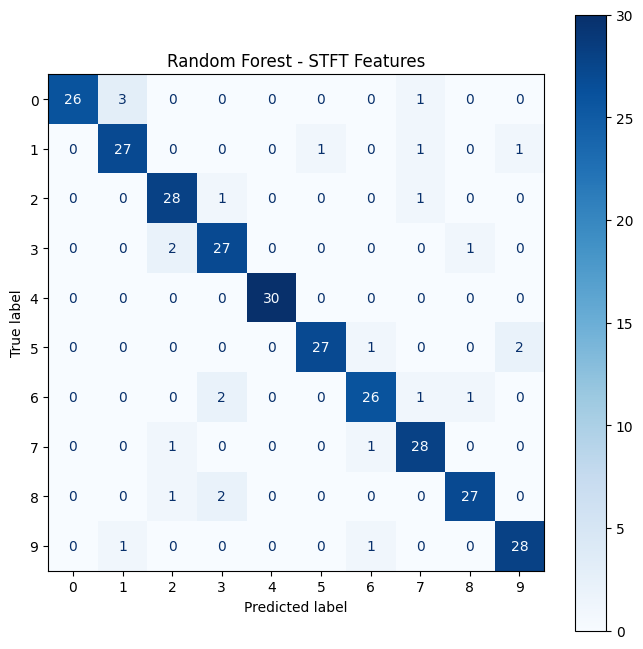


Feature Importance Ranking:
band500_1000_mean: 0.047219
rolloff_min: 0.046477
band500_1000_std: 0.037260
band1000_2000_min: 0.035220
band500_1000_max: 0.033649
rolloff_std: 0.031501
rolloff_mean: 0.030586
band500_1000_min: 0.029218
band0_500_mean: 0.027762
band2000_4000_min: 0.027734
bandwidth_min: 0.026167
rms_max: 0.025397
bandwidth_mean: 0.024134
band0_500_max: 0.023867
centroid_min: 0.023079
bandwidth_std: 0.021196
rms_std: 0.019706
centroid_mean: 0.018936
flatness_min: 0.016937
centroid_skew: 0.016687
band0_500_skew: 0.016658
rms_skew: 0.016443
domfreq_mean: 0.015712
domfreq_max: 0.014699
flatness_mean: 0.013970
band1000_2000_mean: 0.013626
centroid_max: 0.013470
domfreq_std: 0.013345
flatness_std: 0.013236
bandwidth_skew: 0.012929
rms_kurtosis: 0.012925
band500_1000_skew: 0.012689
centroid_std: 0.012299
bandwidth_max: 0.012214
band2000_4000_mean: 0.012181
band500_1000_kurtosis: 0.012164
band0_500_kurtosis: 0.012017
flatness_max: 0.011707
band1000_2000_std: 0.011609
band0_500_min

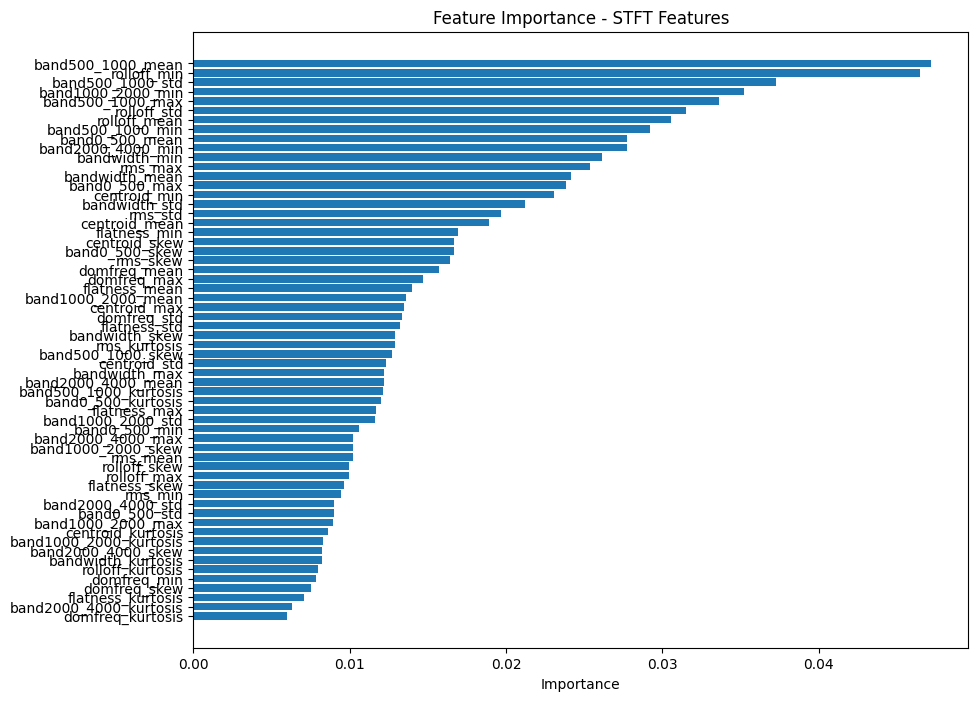

In [ ]:
# STFT-BASED AUDIO CLASSIFICATION - Approach 1
RF_PARAMS = {
    "n_estimators": 400,
    "max_depth": 15,
    "min_samples_split": 4,
    "min_samples_leaf": 2,
    "max_features": "sqrt",
    "random_state": 42
}

# !! Error Handling only is created with the help of Copilot !!

def find_filename(file_path: Path):
    """
    Parse filename of the form:
    digit_speaker_index.wav

    Example:
    0_jackson_32.wav -> (0, 'jackson', 32)
    """
    try:
        parts = file_path.stem.split("_")

        if len(parts) != 3:
            raise ValueError(
                f"Invalid filename format for '{file_path.name}'. "
                f"Expected digit_speaker_index.wav"
            )

        digit = int(parts[0])
        speaker = parts[1]
        index = int(parts[2])

        return digit, speaker, index

    except Exception as e:
        raise ValueError(f"Failed to get filename '{file_path.name}': {e}")

def get_wav_files(data_dir: Path):
    """
    Return sorted list of WAV files from the dataset directory.
    """
    if not data_dir.exists():
        raise FileNotFoundError(f"Dataset directory does not exist: {data_dir}")

    if not data_dir.is_dir():
        raise NotADirectoryError(f"Provided path is not a directory: {data_dir}")

    files = sorted(data_dir.glob("*.wav"))

    if len(files) == 0:
        raise FileNotFoundError(f"No .wav files found in: {data_dir}")

    return files

def load_audio(file_path: Path):
    """
    Load audio and normalize amplitude.
    Same logic as your original code.
    """
    try:
        y, sr = librosa.load(file_path, sr=None, mono=True)

        if y is None or len(y) == 0:
            raise ValueError("Loaded waveform is empty.")

        max_abs = np.max(np.abs(y))
        if max_abs > 0:
            y = y / max_abs

        return y, sr

    except Exception as e:
        raise RuntimeError(f"Failed to load audio '{file_path.name}': {e}")


# FEATURE EXTRACTION
def safe_stats(x):
    """
    Compute:
    min, max, mean, std, skewness, kurtosis

    Same logic as your original code.
    computed per frame feature
     """
    x = np.asarray(x, dtype=float)

    min_val = np.min(x)
    max_val = np.max(x)
    mean_val = np.mean(x)
    std_val = np.std(x)

    if np.allclose(std_val, 0):
        skew_val = 0.0
        kurt_val = 0.0
    else:
        skew_val = skew(x, bias=False)
        kurt_val = kurtosis(x, fisher=False, bias=False)

        if np.isnan(skew_val):
            skew_val = 0.0
        if np.isnan(kurt_val):
            kurt_val = 0.0

    return [min_val, max_val, mean_val, std_val, skew_val, kurt_val]


def extract_stft_features(
    file_path: Path,
    n_fft: int = 512,
    win_length: int = 512,
    hop_length: int = 64,
    window: str = "hann"
):
    """
    Extract the same STFT-based features (computed per frame)
    - centroid
    - bandwidth
    - rolloff
    - flatness
    - rms
    - dominant frequency
    - band-energy ratios
    Then summarize each with safe_stats().
    """
    try:
        y, sr = load_audio(file_path)
        """
         STFT (return complex matrix spectrum coefficient per frame
          (#N frames *spectrum coefficient )
        """

        S = librosa.stft(
            y,
            n_fft=n_fft,
            win_length=win_length,
            hop_length=hop_length,
            window=window
        )

        magnitude = np.abs(S)
        power = magnitude ** 2

        # Frame-wise STFT spectral features
        centroid = librosa.feature.spectral_centroid(S=magnitude, sr=sr)[0]
        bandwidth = librosa.feature.spectral_bandwidth(S=magnitude, sr=sr)[0]
        rolloff = librosa.feature.spectral_rolloff(
            S=magnitude,
            sr=sr,
            roll_percent=0.85
        )[0]
        flatness = librosa.feature.spectral_flatness(S=magnitude)[0]

        # RMS with matching frame length
        rms = librosa.feature.rms(S=magnitude, frame_length=n_fft)[0]

        # Dominant frequency per frame
        freqs = librosa.fft_frequencies(sr=sr, n_fft=n_fft)
        dominant_bin = np.argmax(magnitude, axis=0)
        dominant_freq = freqs[dominant_bin]

        # Band-energy ratios per frame
        total_power_per_frame = np.sum(power, axis=0) + 1e-12

        def band_ratio(f_low, f_high):
            idx = np.where((freqs >= f_low) & (freqs < f_high))[0]
            if len(idx) == 0:
                return np.zeros(power.shape[1])
            return np.sum(power[idx, :], axis=0) / total_power_per_frame

        band_0_500 = band_ratio(0, 500)
        band_500_1000 = band_ratio(500, 1000)
        band_1000_2000 = band_ratio(1000, 2000)
        band_2000_4000 = band_ratio(2000, 4000)

        # Statistical summaries
        features = (
            safe_stats(centroid)
            + safe_stats(bandwidth)
            + safe_stats(rolloff)
            + safe_stats(flatness)
            + safe_stats(rms)
            + safe_stats(dominant_freq)
            + safe_stats(band_0_500)
            + safe_stats(band_500_1000)
            + safe_stats(band_1000_2000)
            + safe_stats(band_2000_4000)
        )

        return np.array(features, dtype=float)

    except Exception as e:
        raise RuntimeError(f"Feature extraction failed for '{file_path.name}': {e}")


def get_feature_names():
    """
    Return the feature names in the same order as the feature vector.
    """
    return [
        "centroid_min", "centroid_max", "centroid_mean", "centroid_std", "centroid_skew", "centroid_kurtosis",
        "bandwidth_min", "bandwidth_max", "bandwidth_mean", "bandwidth_std", "bandwidth_skew", "bandwidth_kurtosis",
        "rolloff_min", "rolloff_max", "rolloff_mean", "rolloff_std", "rolloff_skew", "rolloff_kurtosis",
        "flatness_min", "flatness_max", "flatness_mean", "flatness_std", "flatness_skew", "flatness_kurtosis",
        "rms_min", "rms_max", "rms_mean", "rms_std", "rms_skew", "rms_kurtosis",
        "domfreq_min", "domfreq_max", "domfreq_mean", "domfreq_std", "domfreq_skew", "domfreq_kurtosis",
        "band0_500_min", "band0_500_max", "band0_500_mean", "band0_500_std", "band0_500_skew", "band0_500_kurtosis",
        "band500_1000_min", "band500_1000_max", "band500_1000_mean", "band500_1000_std", "band500_1000_skew", "band500_1000_kurtosis",
        "band1000_2000_min", "band1000_2000_max", "band1000_2000_mean", "band1000_2000_std", "band1000_2000_skew", "band1000_2000_kurtosis",
        "band2000_4000_min", "band2000_4000_max", "band2000_4000_mean", "band2000_4000_std", "band2000_4000_skew", "band2000_4000_kurtosis"
    ]



# DATASET PREPARATION
def build_train_test_sets(
    files,
    n_fft: int,
    win_length: int,
    hop_length: int,
    window: str
):
    """
    Build train/test sets using the same split rule:
    index 0-4 -> test (10%)
    index 5-49 -> train (90%)
    """
    X_train, y_train = [], []
    X_test, y_test = [], []

    for file_path in files:
        digit, speaker, index = find_filename(file_path)

        features = extract_stft_features(
            file_path=file_path,
            n_fft=n_fft,
            win_length=win_length,
            hop_length=hop_length,
            window=window
        )

        if index <= 4:
            X_test.append(features)
            y_test.append(digit)
        else:
            X_train.append(features)
            y_train.append(digit)

    if len(X_train) == 0 or len(X_test) == 0:
        raise RuntimeError("Training or testing set is empty after dataset processing.")

    return (
        np.array(X_train),
        np.array(y_train),
        np.array(X_test),
        np.array(y_test)
    )


# MODELING
def train_random_forest(X_train, y_train, rf_params: dict):
    """
    Train Random Forest using the same parameters as your original code.
    """
    try:
        model = RandomForestClassifier(**rf_params)
        model.fit(X_train, y_train)
        return model
    except Exception as e:
        raise RuntimeError(f"Model training failed: {e}")


def evaluate_model(model, X_test, y_test):
    """
    Evaluate model on test set.
    """
    try:
        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        report = classification_report(y_test, y_pred)
        cm = confusion_matrix(y_test, y_pred)
        return y_pred, acc, report, cm
    except Exception as e:
        raise RuntimeError(f"Model evaluation failed: {e}")


# !! VISUALIZATION is created with the help of copilot !!

# VISUALIZATION
def plot_confusion_matrix(cm, title="Random Forest - STFT Features"):
    """
    Plot confusion matrix.
    """
    fig, ax = plt.subplots(figsize=(8, 8))
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=np.arange(10)
    )
    disp.plot(cmap="Blues", values_format="d", ax=ax)
    plt.title(title)
    plt.show()


def print_feature_importance(model, feature_names):
    """
    Print and plot feature importance ranking.
    """
    importances = model.feature_importances_
    sorted_idx = np.argsort(importances)[::-1]

    print("\nFeature Importance Ranking:")
    for i in sorted_idx:
        print(f"{feature_names[i]}: {importances[i]:.6f}")

    plt.figure(figsize=(10, 8))
    plt.barh(
        [feature_names[i] for i in sorted_idx],
        [importances[i] for i in sorted_idx]
    )
    plt.gca().invert_yaxis()
    plt.xlabel("Importance")
    plt.title("Feature Importance - STFT Features")
    plt.show()


# REPORTING
def print_dataset_summary(files, X_train, y_train, X_test, y_test):
    """
    Print dataset summary and shapes.
    """
    print("Number of files found:", len(files))
    print("First 5 files:")
    for f in files[:5]:
        print(f.name)

    print("\nShapes:")
    print("X_train:", X_train.shape)
    print("y_train:", y_train.shape)
    print("X_test :", X_test.shape)
    print("y_test :", y_test.shape)
    print("Feature vector length:", X_train.shape[1])


def print_results(acc, report):
    """
    Print model results.
    """
    print("\n==============================")
    print("STFT-BASED MODEL RESULTS")
    print("==============================")
    print("Test Accuracy:", acc)
    print("\nClassification Report:")
    print(report)


# MAIN
def main():
    try:
        files = get_wav_files(DATA_DIR)

        X_train, y_train, X_test, y_test = build_train_test_sets(
            files=files,
            n_fft=512,
            win_length=512,
            hop_length=64,
            window='hann'
        )

        print_dataset_summary(files, X_train, y_train, X_test, y_test)

        model = train_random_forest(
            X_train=X_train,
            y_train=y_train,
            rf_params=RF_PARAMS
        )

        y_pred, acc, report, cm = evaluate_model(
            model=model,
            X_test=X_test,
            y_test=y_test
        )

        print_results(acc, report)

        plot_confusion_matrix(cm)
        print_feature_importance(model, get_feature_names())

    except Exception as e:
        print(f"\nFatal error: {e}")


if __name__ == "__main__":
    main()

Number of files found: 3000
First 5 files:
0_george_0.wav
0_george_1.wav
0_george_10.wav
0_george_11.wav
0_george_12.wav

Shapes:
X_train: (2700, 160)
y_train: (2700,)
X_test : (300, 160)
y_test : (300,)
Feature vector length: 160

STFT BLOCK-FEATURE MODEL RESULTS
Test Accuracy: 0.9566666666666667

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.90      0.93        30
           1       0.97      1.00      0.98        30
           2       0.90      0.93      0.92        30
           3       0.85      0.97      0.91        30
           4       1.00      1.00      1.00        30
           5       1.00      1.00      1.00        30
           6       0.90      0.93      0.92        30
           7       1.00      0.97      0.98        30
           8       1.00      0.90      0.95        30
           9       1.00      0.97      0.98        30

    accuracy                           0.96       300
   macro avg       0.96    

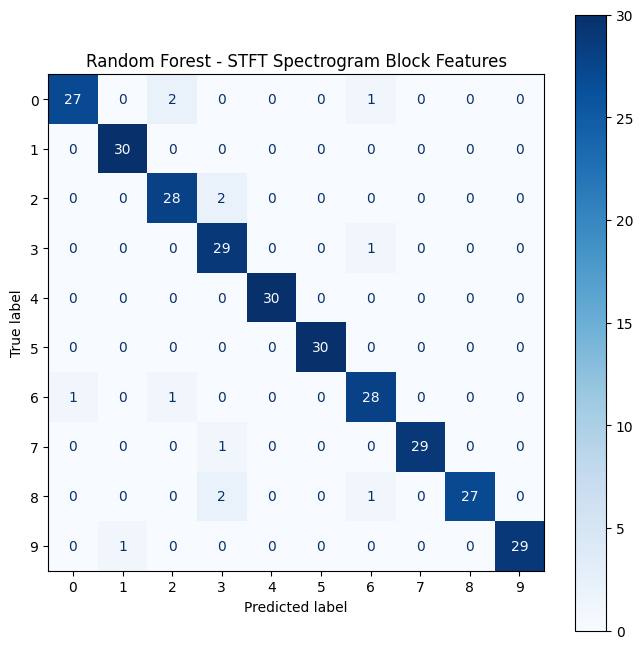


Top 20 Feature Importances:
F2_T3_std: 0.017227
F2_T2_std: 0.015239
F3_T3_mean: 0.014679
F3_T4_mean: 0.014544
F1_T1_mean: 0.013712
F2_T4_mean: 0.013559
F3_T1_std: 0.013417
F2_T4_std: 0.013306
F2_T3_mean: 0.012461
F3_T2_std: 0.012408
F3_T2_mean: 0.012385
F3_T3_std: 0.012364
F3_T4_std: 0.012126
F5_T1_std: 0.011796
F2_T2_mean: 0.011763
F3_T1_mean: 0.011629
F2_T5_mean: 0.010930
F0_T3_std: 0.010714
F1_T7_mean: 0.010467
F5_T1_mean: 0.010422


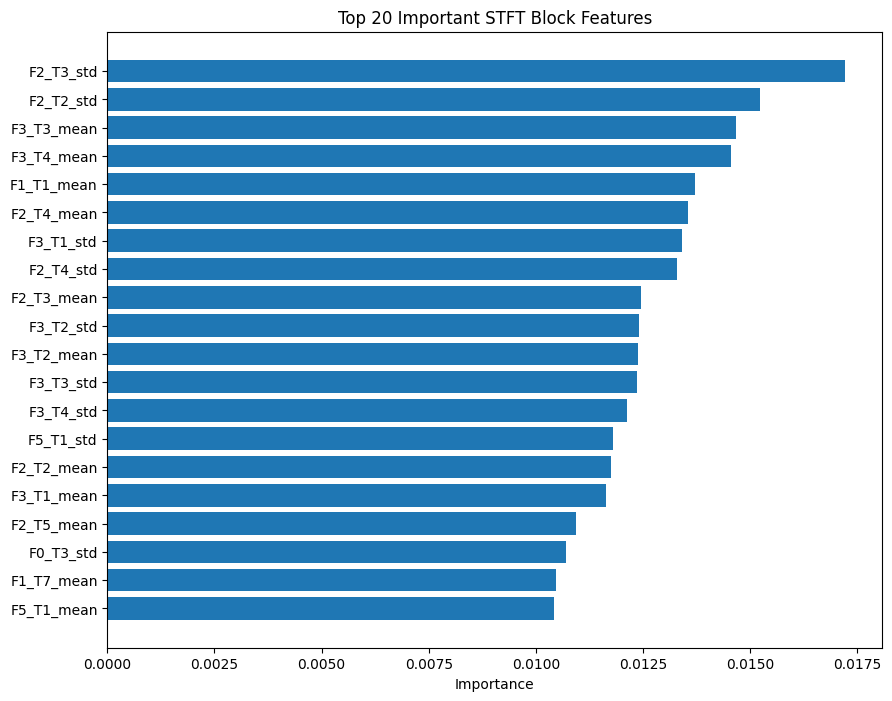

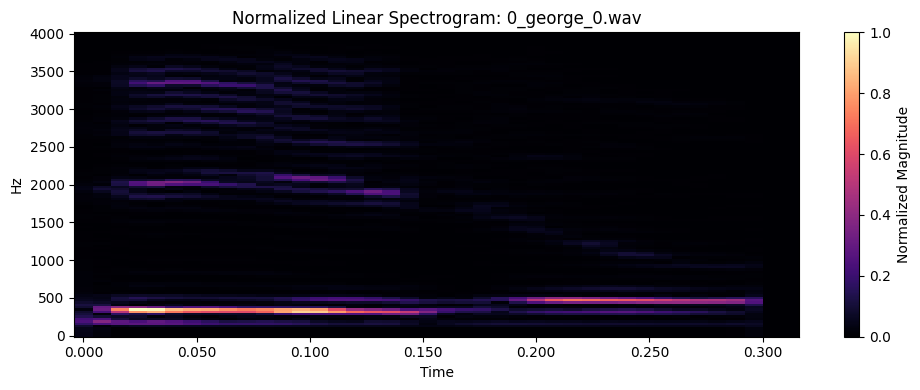

In [ ]:
# STFT SPECTROGRAM-BLOCK FEATURES + RANDOM FOREST

import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# 1) DATASET PATH
DATA_DIR = Path("/content/free-spoken-digit-dataset/recordings")
files = sorted(DATA_DIR.glob("*.wav"))

print("Number of files found:", len(files))
print("First 5 files:")
for f in files[:5]:
    print(f.name)

# 2) STFT PARAMETERS
N_FFT = 256
WIN_LENGTH = 256
HOP_LENGTH = 64
WINDOW = "hann"
# 3) BLOCK PARAMETERS
# Number of blocks along frequency and time
N_FREQ_BLOCKS = 10
N_TIME_BLOCKS = 8

# Force every spectrogram to have the same number of time frames
FIXED_TIME_FRAMES = 40

# 4) HELPER FUNCTIONS
def parse_filename(file_path):
    """
    Example:
    0_jackson_32.wav

    Returns:
    digit   -> 0
    speaker -> jackson
    index   -> 32
    """
    parts = file_path.stem.split("_")
    digit = int(parts[0])
    speaker = parts[1]
    index = int(parts[2])
    return digit, speaker, index


def load_audio(file_path):
    """
    Load audio and normalize waveform amplitude.
    """
    y, sr = librosa.load(file_path, sr=None, mono=True)

    max_abs = np.max(np.abs(y))
    if max_abs > 0:
        y = y / max_abs

    return y, sr


def extract_block_spectrogram_features(
    file_path,
    n_fft=256,
    win_length=256,
    hop_length=64,
    window="hann",
    n_freq_blocks=8,
    n_time_blocks=8,
    fixed_time_frames=32
):
    """
    Extract STFT spectrogram-block features.

    Steps:
    1) Compute STFT
    2) Take magnitude spectrogram
    3) Normalize spectrogram by its maximum
    4) Force all files to have the same number of time frames
    5) Split into time-frequency blocks
    6) For each block, compute mean and std

    Returns:
    1D numpy array of features
    """
    y, sr = load_audio(file_path)

    # -------------------------
    # STFT
    # -------------------------
    S = librosa.stft(
        y,
        n_fft=n_fft,
        win_length=win_length,
        hop_length=hop_length,
        window=window
    )

    # Magnitude spectrogram
    spec = np.abs(S)

    # Normalize so loud/quiet recordings are more comparable
    spec = spec / (np.max(spec) + 1e-12)

    # Make all spectrograms have the same number of time frames
    # If shorter -> zero-pad
    # If longer  -> truncate
    spec = librosa.util.fix_length(spec, size=fixed_time_frames, axis=1)

    # Frequency bins are already fixed because n_fft is fixed
    n_freq_bins, n_time_frames = spec.shape

    # Split rows and columns into blocks
    freq_indices = np.array_split(np.arange(n_freq_bins), n_freq_blocks)
    time_indices = np.array_split(np.arange(n_time_frames), n_time_blocks)

    features = []

    # For each time-frequency block, compute mean and std
    for f_idx in freq_indices:
        for t_idx in time_indices:
            block = spec[np.ix_(f_idx, t_idx)]

            block_mean = np.mean(block)
            block_std = np.std(block)

            features.extend([block_mean, block_std])

    return np.array(features, dtype=float)


# 5) FEATURE NAMES
feature_names = []
for fb in range(N_FREQ_BLOCKS):
    for tb in range(N_TIME_BLOCKS):
        feature_names.append(f"F{fb}_T{tb}_mean")
        feature_names.append(f"F{fb}_T{tb}_std")

# 6) BUILD TRAIN / TEST SETS
# index 0-4 -> test
# index 5-49 -> train
X_train = []
y_train = []

X_test = []
y_test = []

for f in files:
    digit, speaker, index = parse_filename(f)

    features = extract_block_spectrogram_features(
        f,
        n_fft=N_FFT,
        win_length=WIN_LENGTH,
        hop_length=HOP_LENGTH,
        window=WINDOW,
        n_freq_blocks=N_FREQ_BLOCKS,
        n_time_blocks=N_TIME_BLOCKS,
        fixed_time_frames=FIXED_TIME_FRAMES
    )

    if index <= 4:
        X_test.append(features)
        y_test.append(digit)
    else:
        X_train.append(features)
        y_train.append(digit)

X_train = np.array(X_train)
y_train = np.array(y_train)

X_test = np.array(X_test)
y_test = np.array(y_test)

print("\nShapes:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test :", X_test.shape)
print("y_test :", y_test.shape)
print("Feature vector length:", X_train.shape[1])

# 7) TRAIN RANDOM FOREST
rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=25,
    min_samples_split=3,
    min_samples_leaf=1,
    max_features="sqrt",
    random_state=42
)

rf.fit(X_train, y_train)

# 8) TEST MODEL
y_pred = rf.predict(X_test)

acc = accuracy_score(y_test, y_pred)

print("\n==============================")
print("STFT BLOCK-FEATURE MODEL RESULTS")
print("==============================")
print("Test Accuracy:", acc)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


# 9) CONFUSION MATRIX
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.arange(10))
disp.plot(cmap="Blues", values_format="d", ax=ax)
plt.title("Random Forest - STFT Spectrogram Block Features")
plt.show()

# 10) FEATURE IMPORTANCE
importances = rf.feature_importances_
sorted_idx = np.argsort(importances)[::-1]

print("\nTop 20 Feature Importances:")
for i in sorted_idx[:20]:
    print(f"{feature_names[i]}: {importances[i]:.6f}")

plt.figure(figsize=(10, 8))
top_k = 20
top_idx = sorted_idx[:top_k]

plt.barh(
    [feature_names[i] for i in top_idx][::-1],
    [importances[i] for i in top_idx][::-1]
)
plt.xlabel("Importance")
plt.title("Top 20 Important STFT Block Features")
plt.show()


# !! VISUALIZATION is created with the help of copilot !!

# 11) VISUALIZE ONE SPECTROGRAM USED BY THE MODEL
example_file = files[0]
y, sr = load_audio(example_file)

S = librosa.stft(
    y,
    n_fft=N_FFT,
    win_length=WIN_LENGTH,
    hop_length=HOP_LENGTH,
    window=WINDOW
)

spec = np.abs(S)
spec = spec / (np.max(spec) + 1e-12)
spec = librosa.util.fix_length(spec, size=FIXED_TIME_FRAMES, axis=1)

plt.figure(figsize=(10, 4))
librosa.display.specshow(
    spec,
    sr=sr,
    hop_length=HOP_LENGTH,
    x_axis="time",
    y_axis="hz"
)
plt.colorbar(label="Normalized Magnitude")
plt.title(f"Normalized Linear Spectrogram: {example_file.name}")
plt.tight_layout()
plt.show()